In [43]:
from PIL import Image as PILImage
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import plotly.express as px
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

**Author:**

Ryan Lindberg  
<rylindberg@ucsd.edu>  
Halıcıoğlu Data Science Institute, UC San Diego

# Tumor Classification from Gene Expression using a Latent Factor Model

---

## Abstract

In this project, we use RNA-Sequencing gene expression data from the TCGA Pan-Cancer dataset to predict tumor type from high dimensional genetic profiles. Totalling ~8300 tumor tissue samples, each sample is represented by a vector of gene expression values across ~16000 genes, and paired with clinical labels indicating its cancer type. To handle the high dimensionality of the expression matrix, we apply latent factor models (PCA) to compress each sample into a low-dimensional representation, then train multinomial logistic regression on these latent factors. We compare this approach against simple baselines (majority class, logistic regression on a small gene subset) using accuracy,  macro-F1, precision/recall and visualize both the latent space and model errors to interpret how well gene expression separates different cancers.


# 1) What is Gene Expression?

Each living organism has DNA, the molecule that carries its genetic instructions.  
Along this DNA strand are **genes** - specific segments that tell the cell how to build particular proteins.  

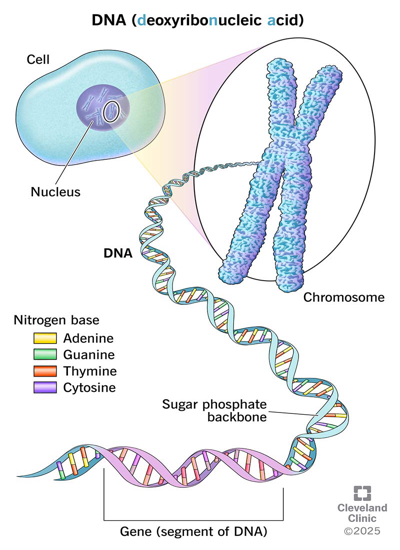

In [27]:
img = PILImage.open('images/DNA.jpg')
img = img.resize((400, 550))
display(img)

**Figure 1:** Schematic of gene segment in DNA.

A gene is **expressed** when its DNA sequence is transcribed into messenger mRNA.

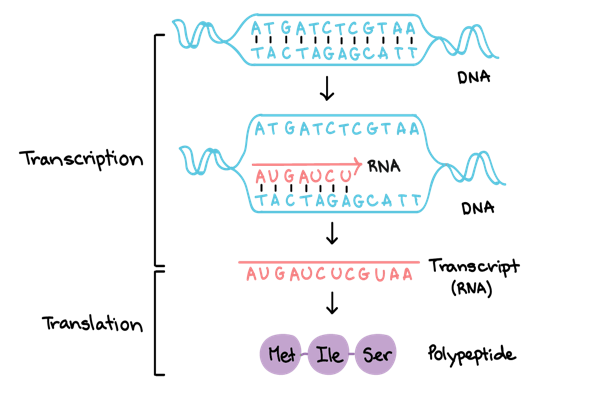

In [28]:
img = PILImage.open('images/transcription.png')
img = img.resize((600, 400))
display(img)

**Figure 2:** Schematic of mRNA transcription and traslation into protein

**RNA-Sequencing** is a technology that measures how much mRNA is produced from each gene, giving us a quantitative readout of gene expression.

# 2) Understanding The Data:

The dataset for this project comes from **“TCGA Pan-Cancer expression and mutation data for Project Cognoma”**, a curated collection of gene expression and mutation profiles derived from The Cancer Genome Atlas (TCGA). This dataset contains thousands of tumor samples across many different cancer types, with each sample represented by a high-dimensional vector of gene expression values plus associated labels (tumor type) and mutation information.

How was the data collected?

1) For each patient, surgeons/pathologists collected tumor tissue at the time of surgery or biopsy 

2) RNA was extracted from each tumor sample.

3) They performed RNA-Sequencing: A next generation sequencing technique used to quantify and identify RNA molecules in a biological sample, providing a comprehensive snapshot of the genes in that sample at that time.


**Source:**  
TCGA Pan-Cancer sample, expression, and mutation data for Project Cognoma  
https://figshare.com/articles/dataset/TCGA_Pan-Cancer_expression_and_mutation_data_for_Project_Cognoma/3487685




## Gene Expression Matrix:

Firstly, we have the gene expression matrix $X$:

In [29]:
X = pd.read_csv("data/expressionmatrix.tsv.bz2", sep="\t", index_col=0)
X.head()

,1,100,1000,10000,100009676,10001,10002,10003,100033416,100033431,...,9987,9988,9989,999,9990,9991,9992,9993,9994,9997
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0047-01,6.98,7.10,11.2,10.30,6.18,8.09,1.16,3.26,7.30,4.64,...,12.0,9.63,10.8,8.05,9.42,10.10,3.66,12.2,8.18,8.23
TCGA-02-0055-01,8.62,7.80,10.8,9.82,6.60,8.33,0.00,5.29,4.36,2.60,...,12.1,9.85,11.0,1.70,8.87,10.40,4.16,11.1,8.28,9.62
TCGA-02-2483-01,8.09,8.00,11.5,10.40,6.12,8.84,2.50,2.79,4.64,2.87,...,12.9,9.73,11.1,4.32,9.15,10.40,3.30,11.4,8.26,8.84
TCGA-02-2485-01,6.41,7.02,12.8,13.30,5.18,8.71,2.64,5.27,6.18,2.53,...,12.7,10.60,10.8,6.83,8.92,9.51,3.64,11.5,8.78,8.74
TCGA-02-2486-01,6.77,7.69,11.1,9.77,6.24,8.79,1.50,6.40,3.80,0.00,...,12.1,9.67,10.2,3.34,8.64,10.10,3.79,10.4,7.98,9.08


In [30]:
print("Tumor Samples: ", X.shape[0])
print("Genes: ", X.shape[1])

Tumor Samples:  8388
Genes:  16261


- **Rows (index: `sample_id`)**  
  - Each row corresponds to **one tumor sample** from a patient.  
  - Example: `TCGA-02-0047-01`, `TCGA-02-0055-01`, etc. are unique sample IDs. 
  - If there are $n$ rows, that means we have expression profiles for $n$ different tumors.

- **Columns (1, 100, 1000, 10000, 100009676, 10001, ..., 9997)**  
  - Each column corresponds to **one gene**.  
  - The column names are **numeric gene identifiers**  
    - Column `1` = expression of the gene with ID 1.  
    - Column `100` = expression of the gene with ID 100 etc.  
  - Biologically, each of these columns is “how active this particular gene is” across all tumor samples.

- **Cell values (the numbers inside the table)**  
  - Each entry is a **gene expression level** for a single sample-gene pair.  
  - Example: the value `6.98` in the row `TCGA-02-0047-01` and column `1` is the expression level of **gene 1** in **tumor sample TCGA-02-0047-01**.  
  - Values like `10.30`, `8.09`, `12.0`, etc. are **normalized and log-transformed** RNA-Seq counts of counts-per-million or a similar measure).  
  - Larger numbers mean **higher expression** (more mRNA from that gene in that sample), smaller numbers mean **lower expression**.

Putting it together:

- The entire matrix `X` is the **RNA-Seq expression matrix**:
  - Shape: $X \in \mathbb{R}^{n \times G}$
    - $n$ = number of tumor samples (rows, `sample_id`s),
    - $G$ = number of genes (columns, numeric gene IDs).
- For each sample $i$, the row vector:
  - $x_i = [X_{i,1}, X_{i,100}, X_{i,1000}, \dots] \in \mathbb{R}^G$
  - is that tumor’s **gene expression profile** across all measured genes.

## Clinical Metadata:

We also have a clinical data table that is paired with the tumor samples:

In [31]:
meta = pd.read_csv("data/samples.tsv", sep="\t") 
meta.set_index("sample_id", inplace=True)
meta.head()

,patient_id,acronym,disease,age_diagnosed,gender,race,ajcc_stage,clinical_stage,histological_type,histological_grade,...,dead,days_survived,disease_specific_survival_status,disease_specific_survival_days,disease_free_interval_status,disease_free_interval_days,progression_free_interval_status,progression_free_interval_days,sample_type,n_mutations
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0047-01,TCGA-02-0047,GBM,glioblastoma multiforme,78.0,Male,White,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,1,448.0,1.0,448.0,NaN,NaN,1,57.0,Primary Solid Tumor,64
TCGA-02-0055-01,TCGA-02-0055,GBM,glioblastoma multiforme,62.0,Female,White,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,1,76.0,1.0,76.0,NaN,NaN,1,6.0,Primary Solid Tumor,51
TCGA-02-2483-01,TCGA-02-2483,GBM,glioblastoma multiforme,43.0,Male,Asian,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,0,466.0,0.0,466.0,NaN,NaN,0,466.0,Primary Solid Tumor,47
TCGA-02-2485-01,TCGA-02-2485,GBM,glioblastoma multiforme,53.0,Male,Black Or African American,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,0,470.0,0.0,470.0,NaN,NaN,1,186.0,Primary Solid Tumor,56
TCGA-02-2486-01,TCGA-02-2486,GBM,glioblastoma multiforme,64.0,Male,White,NaN,NaN,Untreated primary (de novo) GBM,NaN,...,1,618.0,1.0,618.0,NaN,NaN,1,618.0,Primary Solid Tumor,63


In [32]:
# Check all unique disease types in the 'disease' column
print(meta['disease'].unique())
print("Unique cancer types: ", meta['disease'].nunique())


['glioblastoma multiforme' 'lung adenocarcinoma'
 'ovarian serous cystadenocarcinoma' 'lung squamous cell carcinoma'
 'prostate adenocarcinoma' 'uterine corpus endometrioid carcinoma'
 'bladder urothelial carcinoma' 'testicular germ cell tumor'
 'esophageal carcinoma' 'pancreatic adenocarcinoma'
 'kidney papillary cell carcinoma' 'liver hepatocellular carcinoma'
 'cervical & endocervical cancer' 'sarcoma' 'breast invasive carcinoma'
 'thymoma' 'mesothelioma' 'colon adenocarcinoma' 'stomach adenocarcinoma'
 'cholangiocarcinoma' 'kidney clear cell carcinoma' 'thyroid carcinoma'
 'head & neck squamous cell carcinoma' 'rectum adenocarcinoma'
 'skin cutaneous melanoma' 'brain lower grade glioma'
 'diffuse large B-cell lymphoma' 'kidney chromophobe'
 'uterine carcinosarcoma' 'adrenocortical cancer'
 'pheochromocytoma & paraganglioma' 'uveal melanoma']
Unique cancer types:  32


For our **tumor-type prediction with latent factor models**, we only use a small subset of these clinical columns. The key ones are:

- **`sample_id`**
  - Unique identifier for each tumor sample.
  - This is the **index** in `meta` and also the index in our expression matrix `X`.
  - We use `sample_id` to **align** rows in `meta` with rows in `X` (so the clinical label and the gene expression vector refer to the same tumor).

- **`acronym`**
  - Short cancer-type code, for example: `GBM` (glioblastoma multiforme), `BRCA`, `LUAD`, etc.
  - This is what we will use as our **target label** $y$ in the classification task.
- **`disease`**
  - Full text name of the cancer type, e.g. `"glioblastoma multiforme"`.
  - We mainly use this for **interpretation and visualization**

- **`age_diagnosed`** (optional feature)
  - Age of the patient at diagnosis (e.g., `78.0`, `62.0`, etc.).

- **`gender`** (optional feature)
  - Categorical variable
  - In many cases, we would use `gender` more for **descriptive statistics** (e.g., how performance varies across genders) rather than as a primary predictor.


# 3) Identifying the Predictive task:

Now that the data is clearly defined, lets take some time to properly understand the predictive task.

## Goal:

Our goal in this project is to use RNA-Sequencing gene expression data from the matrix $X$ to **predict tumor type from a patient’s tumor sample**. Concretely, each sample is represented by a high dimensional vector of gene expression values, and labeled with a cancer type acronym from the clinical metadata. We aim to learn a mapping from expression profiles to cancer types that can accurately distinguish between different tumors.

To make this feasible and robust in the high dimensional setting (thousands of genes, relatively few samples), we will:

- Compress the expression matrix into a **low dimensional latent representation** using PCA (latent factor model).
- Train a **multinomial logistic regression** classifier on these latent factors to predict tumor type.
- Compare this model against simple baselines (majority class predictor and logistic regression) using accuracy, confidence score, per class recall, and per class precision. 

Ultimately, the goal is to show that latent factors extracted from gene expression carry enough information to meaningfully separate cancer types, while also understanding where the model succeeds, where it fails, and what that implies for potential real world use as a decision support tool.


### Motivation:

You might be asking yourself, 

*"Since we acquired the tissue sample from the tumor, shouldn't we already know what type of cancerous tumor it is just based off the location?"*

That is a very valid question.

The short answer is: **No**, we don’t always know the true type of the cancer just from where the sample came from.

We have to consider many things:

1) **Metastatic tumors**

For example, suppose a patient shows up with a liver metastasis (when cancer cells spread from the original (primary) tumor to other parts of the body). 

 - That tumor in the liver might be:

    - primary liver cancer

    - breast cancer that spread to the liver

    - colon cancer that spread to the liver, etc.

The primary site is literally unknown, and this classifier we are building can help answer the question of: 

“From this biopsy alone, what’s the most likely tissue of origin?” which can help track down the primary source of the cancer.


2) **Different cancers in the same organ** 

For example, in the brain you can have different types such as glioblastoma (GBM), oligodendroglioma (ODG), metastasis from lung, etc.

A genetic identifier like this one could potentially help pathologists differentiate between tumors and give patients the correct treatment.

3) **Cancer subtypes**

“Breast invasive carcinoma” isn’t a single disease. There are many subclasses that can be discovered through measuring certain things about the tumor.

These attributes and subclasses add nuance and difficulty to the identification process of a tumor. If we can use gene expression to aid in this identification, we can help patients receive the right care more quickly.

Now before we build the model, we should discuss how we will evaluate it. 

### Model Evaluation:

**How should we evaluate the performance of our model?**

We need to consider a few things to answer this question:

1) How could this model actually be used?

    - Pathologist is unsure. RNA-Sequencing is run, model says: “this looks most like lung cancer/ GBM / etc.” Clinician uses that as one more piece of evidence, not the final say.

    - Quality control: Compare model predicted tumor type vs. recorded pathology. Large deviations might flag possible labeling errors, sample swaps, or miscoded cases.

    - Cancer subtyping: With more complex models you can learn subtypes inside a cancer (e.g., GBM subtypes). That info can feed into prognosis or “which clinical trial is appropriate” type decisions.

    - Research: understanding biology: Use latent factors to see which cancer types cluster together. Identify gene programs that separate, say, GBM from lower-grade glioma. 

2) How can we evaluate it within the context of the problem?

    - Accuracy (the proportion of tumors correctly classified).

    - Macro-F1: On average, for each tumor type, how often do we avoid false negatives and false positives?
    
    - Per class recall ($\frac{TP}{TP+FN}$): Out of all the tumors of this type, what proportion did we classify correctly? We want to ensure there are no cancer types that are consistently misclassified.

    - Per class precision ($\frac{TP}{TP+FP}$): If the model predicts "GBM", how often is it actually GBM? Mislabeling one type of cancer for another may have real consequences. For example, a benign tumor (noncancerous) as something more harmful.

3) Major concerns/possible failures?

    - Selection Bias: The tumor samples covered in the TCGA dataset may not be representative of all tumor samples. The model could work well with TCGA style patients, but poorly on other patients. 

    - Limited data: In practice, pathologists will often use many metrics to determine the type and severity of a cancerous tumor such as imagery, clinical history, histology. Our dataset only uses gene expression.

    - Interpretability of latent factors: The PCA components are linear combinations of thousands of genes. Explaning *why* the model makes certain predictions is a non trivial task. In a clinical setting, regulators and clinicians would want more transparency behind the reasoning of the model.

    - Ethical risk of misclassification: Wrong tumor type → wrong care, wrong chemo. Misclassifications carry serious real world consequences if acted upon. Any real deployment of this model needs rigorous validation, i.e. a human in the loop such that the model cannot override human decisions, and clear guidance for when the model should be ignored.

### Model Validation:

**Does this model’s output make sense and remain reliable in the context of real tumor classification?**

To ensure model validity we can use basic validation methods as such:


1) **K-fold cross validation**: Test the model repeatedly on unseen data during training which reduces bias and helps detect overfitting. The result is a better estimate of how the model will perform on unseen real world data.

2) Analyze **performance metrics**.

3) Explicitly examine **rare classes** to check whether the model is failing on underrepresented cancer types, visualize latent factors to see whether cancer types form coherent clusters in the learned representation.


Together, these methods will help us quantify whether the model is genuinely learning from the data rather than random noise.



### Baseline Comparisons

To see if our latent factor model is truly learning from the data and performing better than a simple model would, we will define a set of baseline models for comparison. These baselines help to answer the question:

*“Is the latent factor + logistic regression pipeline actually useful, or could a much simpler model do just as well?”*

The baselines we will use are: 1) a **simple logistic regression model**, and 2) a **"majority class" model** which always predicts the most common class.

We will see how these baselines stack up against our latent factor model in the evaluation section.


# 4) Exploratory Data Analysis and Preprocessing:

### 1) Clinical metadata:

Starting with clinical metadata lets drop unnecessary columns.

In [33]:
meta = meta[["acronym", "disease", "age_diagnosed", "gender"]].copy()
meta.head()

,acronym,disease,age_diagnosed,gender
sample_id,,,,
TCGA-02-0047-01,GBM,glioblastoma multiforme,78.0,Male
TCGA-02-0055-01,GBM,glioblastoma multiforme,62.0,Female
TCGA-02-2483-01,GBM,glioblastoma multiforme,43.0,Male
TCGA-02-2485-01,GBM,glioblastoma multiforme,53.0,Male
TCGA-02-2486-01,GBM,glioblastoma multiforme,64.0,Male


Lets take a look at some of the basic summary statistics:

In [34]:
# Number of unique cancer types
print("Number of unique cancer types in the dataset:", (meta.loc[X.index,"disease"]).value_counts().nunique())
# Number of tumor samples
print("Number of tumor tissue samples:", meta.shape[0])

Number of unique cancer types in the dataset: 32
Number of tumor tissue samples: 8388


Lets visualize the distribution of these tumor samples by cancer type:

In [35]:
# Number of samples per cancer type with proportions
counts = meta.loc[X.index, "disease"].value_counts()
percentages = counts / len(meta.loc[X.index, "disease"]) * 100
cancer_stats = pd.DataFrame({'Sample Count': counts, 'Percentage': np.round(percentages, 2)})
print(cancer_stats)

                                       Sample Count  Percentage
disease                                                        
breast invasive carcinoma                       787        9.38
brain lower grade glioma                        510        6.08
lung adenocarcinoma                             508        6.06
head & neck squamous cell carcinoma             499        5.95
prostate adenocarcinoma                         492        5.87
thyroid carcinoma                               489        5.83
lung squamous cell carcinoma                    477        5.69
uterine corpus endometrioid carcinoma           436        5.20
stomach adenocarcinoma                          411        4.90
bladder urothelial carcinoma                    403        4.80
kidney clear cell carcinoma                     366        4.36
liver hepatocellular carcinoma                  357        4.26
colon adenocarcinoma                            287        3.42
cervical & endocervical cancer          

Lets take a look at the distribution of cancer types with a bar graph:

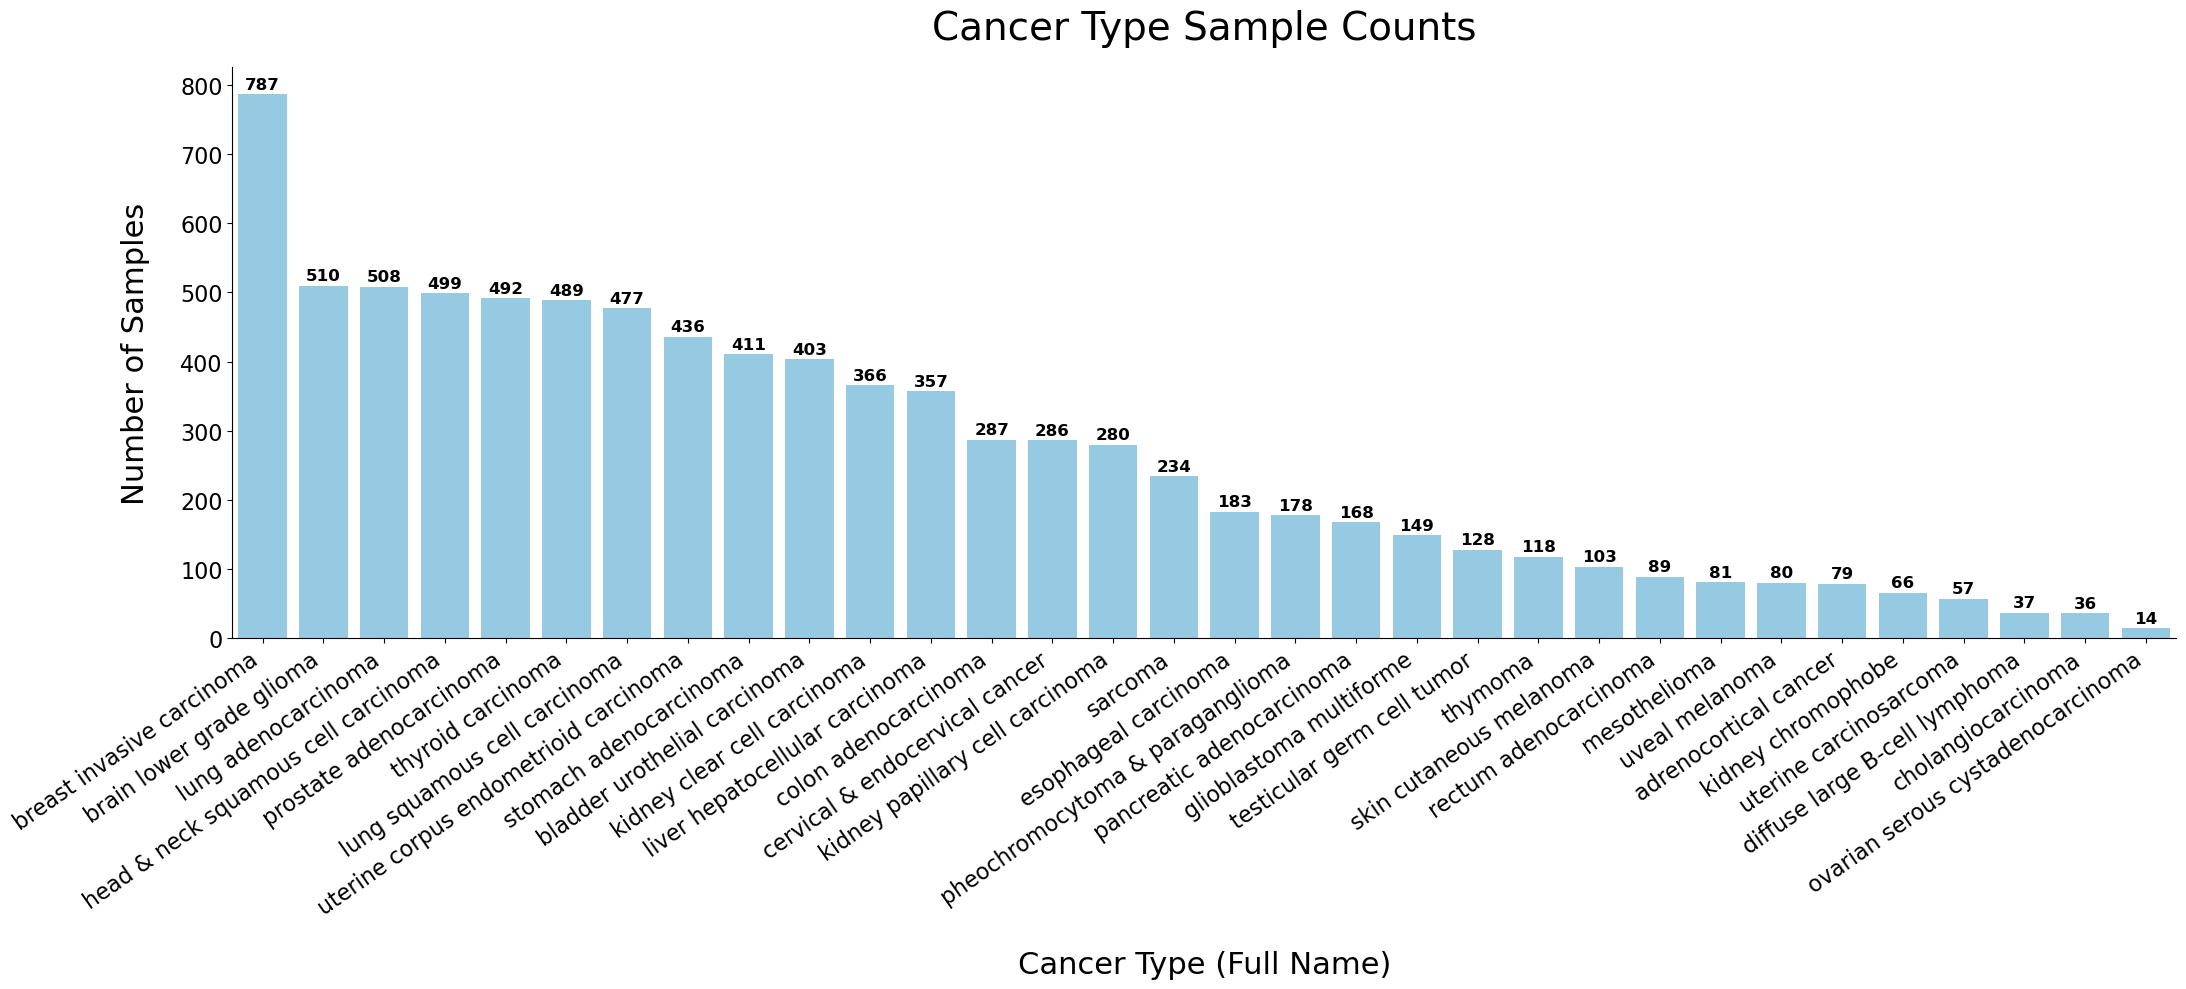

In [36]:
cancer_stats_sorted = cancer_stats.sort_values("Sample Count", ascending=False).reset_index()
cancer_stats_sorted.columns = ["Cancer Type", "Sample Count", "Percentage"]

plt.figure(figsize=(22, 10))

bar_color = "#89CFF0"

ax = sns.barplot(
    data=cancer_stats_sorted,
    x="Cancer Type",
    y="Sample Count",
    color=bar_color
)

plt.title('Cancer Type Sample Counts', fontsize=28, pad=20)
plt.xlabel('Cancer Type (Full Name)', fontsize=22, labelpad=22)
plt.ylabel('Number of Samples', fontsize=22, labelpad=22)
plt.xticks(
    ticks=range(len(cancer_stats_sorted["Cancer Type"])),
    labels=cancer_stats_sorted["Cancer Type"],
    fontsize=16,
    rotation=35,
    ha='right'
)
plt.yticks(fontsize=16)

for i, v in enumerate(cancer_stats_sorted["Sample Count"]):
    ax.text(i, v + max(cancer_stats_sorted["Sample Count"])*0.01, str(v), ha="center", fontsize=12, fontweight="semibold")

sns.despine()
plt.tight_layout()
plt.show()

Additionally, we can look at how gender plays a role in cancer type. Lets examine the gender distribution:

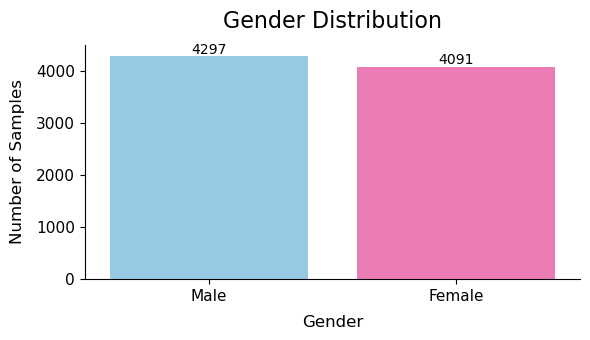

In [37]:
gender_counts = meta.loc[X.index, "gender"].value_counts().reindex(["Male", "Female"]).fillna(0).astype(int)

gender_df = gender_counts.reset_index()
gender_df.columns = ["Gender", "Count"]

plt.figure(figsize=(6, 3.5))

palette = ["#89CFF0", "#ff69b4"] if set(gender_df["Gender"]) == {"Male", "Female"} or set(gender_df["Gender"]) == {"Female", "Male"} else "pastel"

ax = sns.barplot(
    data=gender_df,
    x="Gender",
    y="Count",
    hue="Gender",
    dodge=False,
    legend=False,
    palette=palette
)
plt.title("Gender Distribution", fontsize=16, pad=12)
plt.xlabel("Gender", fontsize=12, labelpad=8)
plt.ylabel("Number of Samples", fontsize=12, labelpad=8)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
for i, v in enumerate(gender_df["Count"].values):
    ax.text(i, v + max(gender_df["Count"].values) * 0.01, str(v), ha="center", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

Heres a simple plot to show the relationship between gender and cancer type:


<Figure size 1800x800 with 0 Axes>

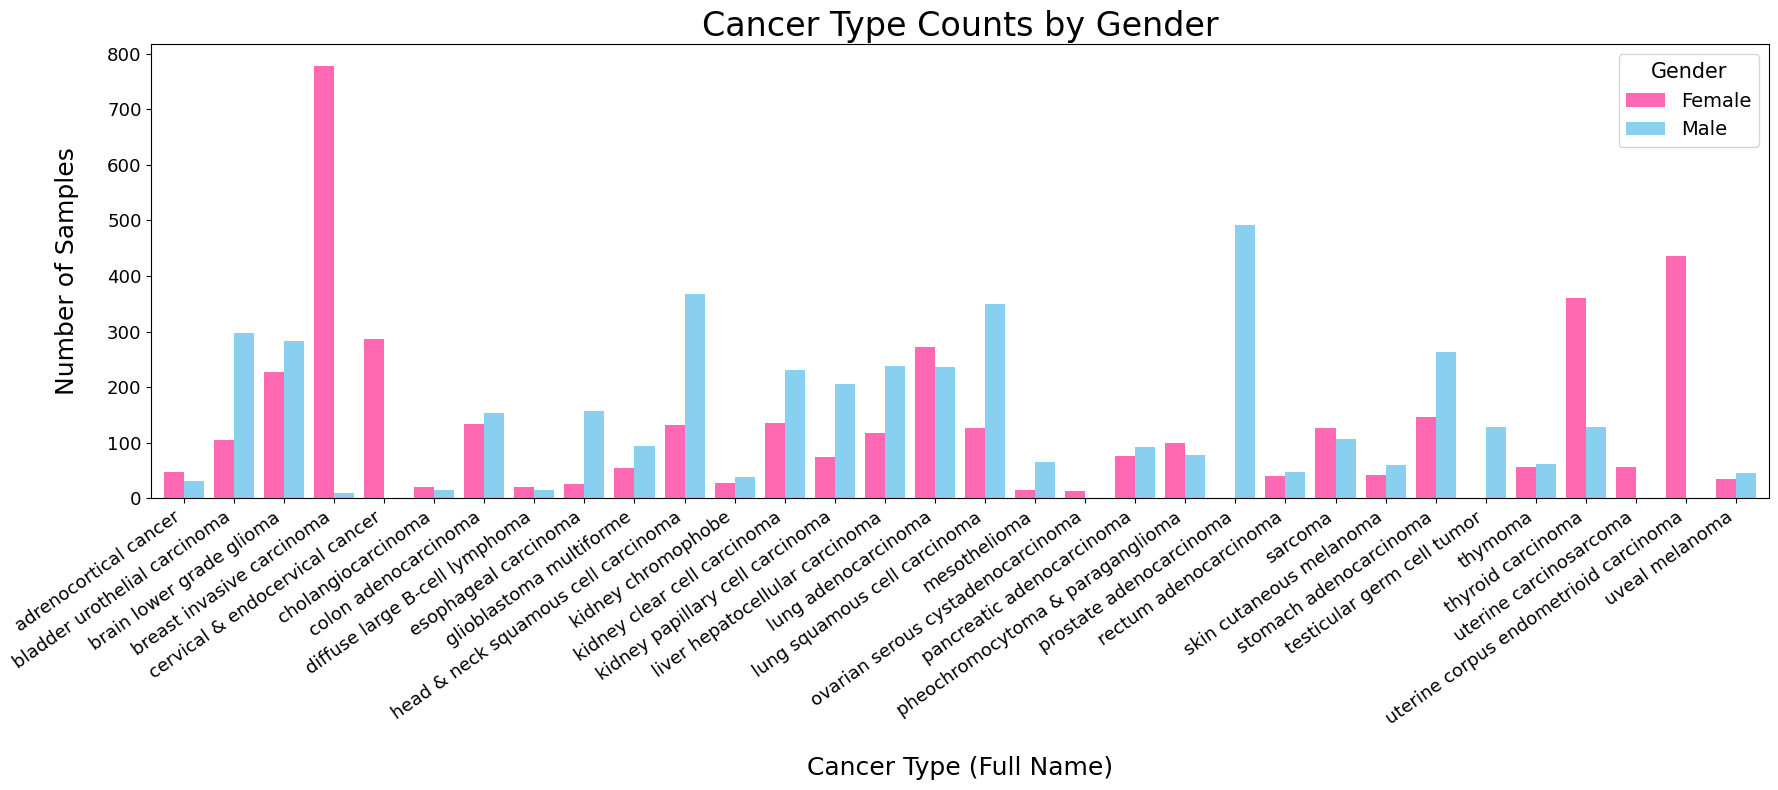

In [38]:
plt.figure(figsize=(18, 8))

gender_cancer_counts = meta.groupby(['disease', 'gender']).size().unstack(fill_value=0)

gender_colors = []
if "Female" in gender_cancer_counts.columns:
    gender_colors.append("#ff69b4")  
if "Male" in gender_cancer_counts.columns:
    gender_colors.append("#89CFF0")  

col_color_map = {
    "Female": "#ff69b4", 
    "Male": "#89CFF0" 
}
colors = [col_color_map.get(g, "#cccccc") for g in gender_cancer_counts.columns]

ax = gender_cancer_counts.plot(
    kind='bar',
    stacked=False,
    width=0.8,
    figsize=(18, 8),
    color=colors
)

plt.title('Cancer Type Counts by Gender', fontsize=24)
plt.xlabel('Cancer Type (Full Name)', fontsize=18, labelpad=20)
plt.ylabel('Number of Samples', fontsize=18, labelpad=20)
plt.xticks(fontsize=13, rotation=35, ha='right')
plt.yticks(fontsize=13)
plt.legend(title='Gender', fontsize=14, title_fontsize=15)
plt.tight_layout()
plt.show()


Looking at this chart, its important to note that there are roughly the same amount of males and females in the dataset.

So what can we learn from this?

**Certain cancer types are male/female dominated.** 

- Females dominate in breast cancer, cervical cancer, uterine cancer, and thyroid cancer.

- Males dominate in head & neck cancer, prostate cancer, esophagus cancer, lung cancer, and bladder cancer.

##### How does age correlate with cancer type?

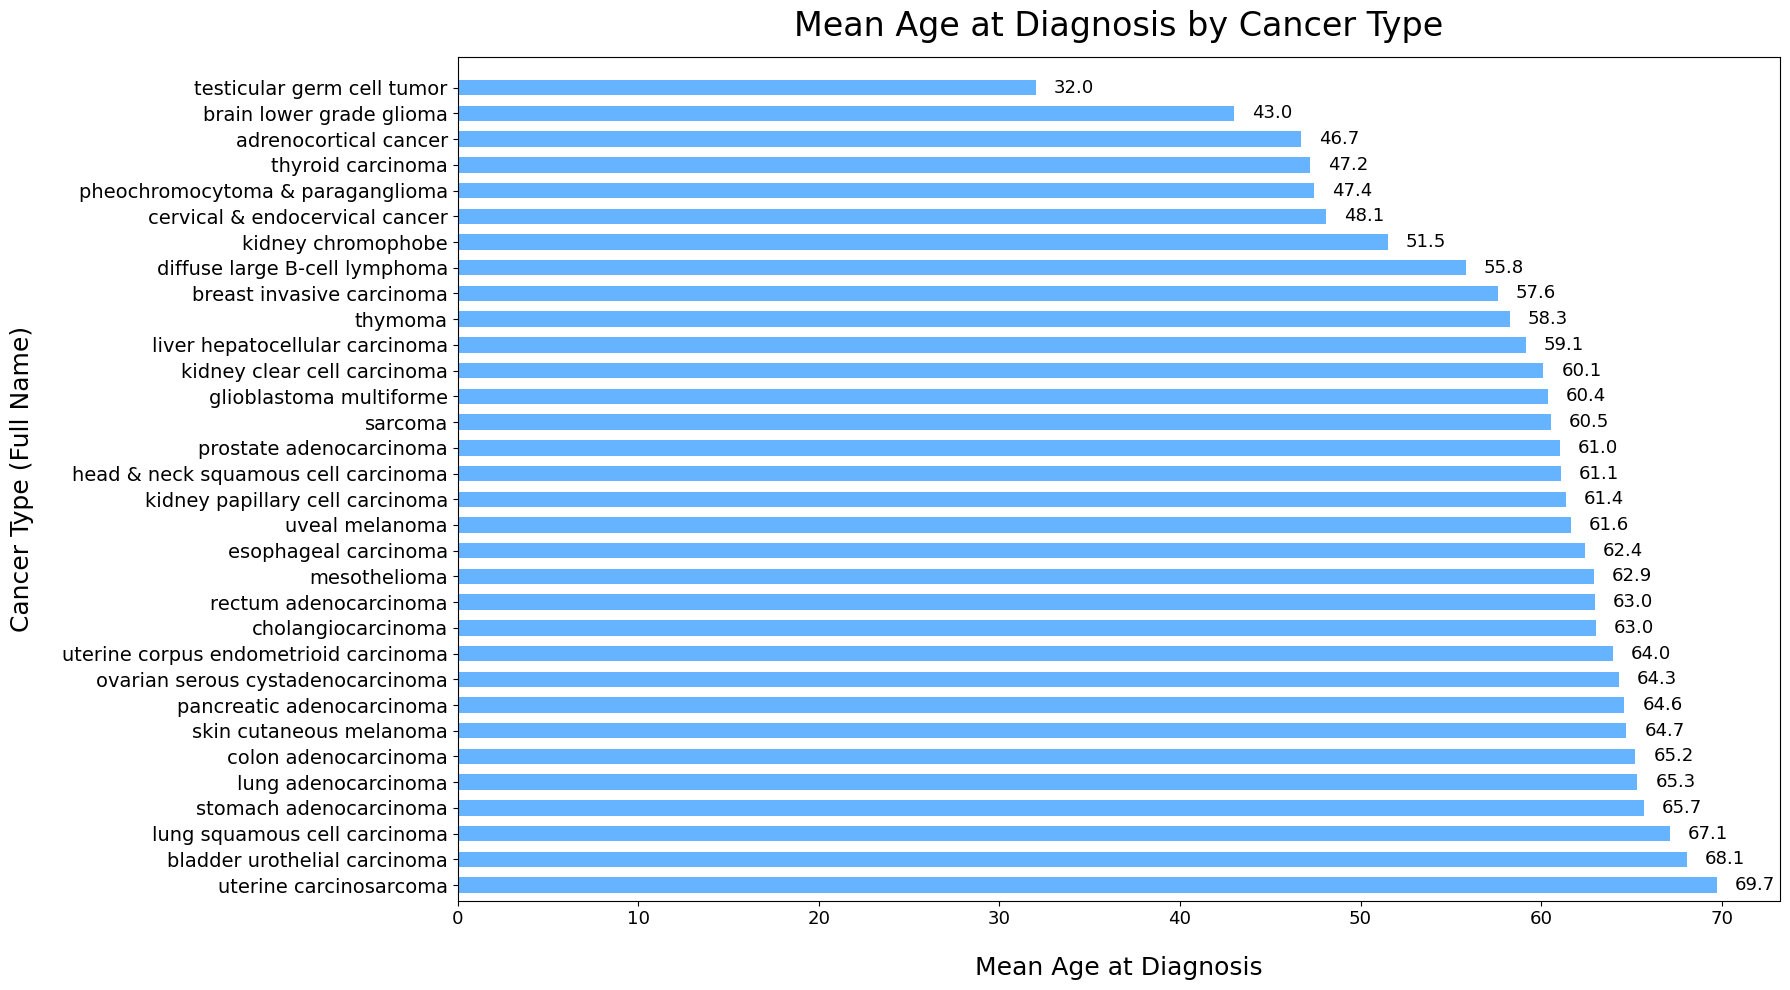

In [39]:

cancer_age = meta.groupby("disease")["age_diagnosed"].mean().sort_values(ascending=False)
bar_color = "#66b3ff"
n = len(cancer_age)

bar_spacing = 4
bar_height = 2.4

bar_positions = np.arange(0, n * bar_spacing, bar_spacing)  # e.g. 0, 4, 8, 12, ...

fig, ax = plt.subplots(figsize=(18, 10))

ax.barh(
    bar_positions,
    cancer_age.values,
    color=bar_color,
    height=bar_height,
    edgecolor='none'
)

ax.set_yticks(bar_positions)
ax.set_yticklabels(cancer_age.index, fontsize=14)

plt.title('Mean Age at Diagnosis by Cancer Type', fontsize=24, pad=15)
plt.xlabel('Mean Age at Diagnosis', fontsize=18, labelpad=20)
plt.ylabel('Cancer Type (Full Name)', fontsize=18, labelpad=20)
plt.xticks(fontsize=13)

ax.set_ylim(-bar_height, bar_positions[-1] + bar_height * 2)

for pos, v in zip(bar_positions, cancer_age.values):
    ax.text(
        v + 1,
        pos,
        f"{v:.1f}",
        va='center',
        fontsize=13,
        color='black'
    )

plt.tight_layout()
plt.show()


Here, we dont see the same degree of variance as we did with gender. It seems that most cancers occer from ages 55 - 70. 

In principle, for latent factor models, the addition of these features adds no expressive power to the model. We could have a features that tell us age and gender, but if this feature were useful, the model would "discover" a latent dimension corresponding to gender, and we wouldn't need the feature anyway.

In the limit, this argument is valid: as we add samples, and more genes per sample, the latent-factor model should automatically discover any useful dimensions of variation, so the influence of observed features will disappear.

Because of this, we will just use the matrix $X$ for our latent factor model, without the added complexity of these additional clinical features.

### 2) Gene expression matrix:

Exploring and visualizing $X$:

In [40]:
X.head()

,1,100,1000,10000,100009676,10001,10002,10003,100033416,100033431,...,9987,9988,9989,999,9990,9991,9992,9993,9994,9997
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0047-01,6.98,7.10,11.2,10.30,6.18,8.09,1.16,3.26,7.30,4.64,...,12.0,9.63,10.8,8.05,9.42,10.10,3.66,12.2,8.18,8.23
TCGA-02-0055-01,8.62,7.80,10.8,9.82,6.60,8.33,0.00,5.29,4.36,2.60,...,12.1,9.85,11.0,1.70,8.87,10.40,4.16,11.1,8.28,9.62
TCGA-02-2483-01,8.09,8.00,11.5,10.40,6.12,8.84,2.50,2.79,4.64,2.87,...,12.9,9.73,11.1,4.32,9.15,10.40,3.30,11.4,8.26,8.84
TCGA-02-2485-01,6.41,7.02,12.8,13.30,5.18,8.71,2.64,5.27,6.18,2.53,...,12.7,10.60,10.8,6.83,8.92,9.51,3.64,11.5,8.78,8.74
TCGA-02-2486-01,6.77,7.69,11.1,9.77,6.24,8.79,1.50,6.40,3.80,0.00,...,12.1,9.67,10.2,3.34,8.64,10.10,3.79,10.4,7.98,9.08


Check the validity/soundness of the data:

In [41]:
print("Shape of matrix X:", X.shape)
print("Non float64 values:", sum(X.dtypes.values != "float64"))
print("NaN values:", X.isna().sum().sum())


Shape of matrix X: (8388, 16261)
Non float64 values: 0
NaN values: 0


The best way to visualize this high dimensional genetic data makes use of the same method we'll use in our prediction model; PCA. (We'll dive into the details of PCA later)

The following plot shows how tumors differ along the top three axes of variation:

In [45]:

# 1. Standardize expression matrix and run PCA (3D)
scaler = StandardScaler(with_mean=True, with_std=True)
X_scaled = scaler.fit_transform(X.values)  

pca_3d = PCA(n_components=3, random_state=0)
Z_3d = pca_3d.fit_transform(X_scaled)      

# 2. Build DataFrame with PCA coords + labels
df_pca3d = pd.DataFrame({
    "PC1": Z_3d[:, 0],
    "PC2": Z_3d[:, 1],
    "PC3": Z_3d[:, 2],
    "cancer_type": meta.loc[X.index, "disease"].astype(str),
    "disease": meta.loc[X.index, "disease"].astype(str)
})

color_col = "cancer_type" 

# 3. 3D PCA scatter with plotly 
fig = px.scatter_3d(
    df_pca3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color=color_col,
    hover_data=["cancer_type", "disease"],
    title="3D PCA of Gene Expression Colored by Tumor Type",
)

fig.update_traces(marker=dict(size=4, opacity=0.8))
fig.update_layout(
    legend=dict(
        itemsizing="constant"
    ),
    scene=dict(
        xaxis_title="PC1",
        yaxis_title="PC2",
        zaxis_title="PC3",
    ),
    width=1200,  
    height=900    
)

fig.show()

Think of the 3D PCA plot as a map of “expression space” where each dot is a tumor and the axes are abstract “expression programs” (linear combinations of genes) that explain the most variation in the data.

- The axes PC1, PC2, PC3 are principal components:

- Each PC is a direction in gene space that captures as much variance as possible, subject to being orthogonal to the others.

- One tumor is marked by a point $z_s = (PC_1, PC_2, PC_3)$  where each coordinate is a weighted sum of thousands of genes.

# Modeling:

### 1) Machine Learning Model:

Our goal is to build a machine learning model that takes a high-dimensional **gene expression profile** for a tumor and predicts its **tumor type**.

- **Inputs (features)**  
  - For each sample $i$, we have a vector of gene expression values:
    $
    x_i \in \mathbb{R}^G,
    $
    where $G$ is the number of genes (columns in the expression matrix $X$). Each entry $x_{i,g}$ represents the (normalized, log-transformed) RNA-Seq expression level of gene $g$ in tumor sample $i$.

- **Outputs (labels)**  
  - From the clinical metadata, each sample has a cancer-type acronym (e.g., `GBM`, `BRCA`, `LUAD`). We encode this as:
    $y_i \in 1, \dots, K,$
    where $K$ is the number of distinct tumor types, and each integer corresponds to one cancer-type acronym.

- **Latent factor representation**  
  - Because $G$ (number of genes) is large and $n$ (number of samples) is relatively small, we first compress $x_i$ into a lower-dimensional **latent factor** representation using PCA:
    $
    z_i \in \mathbb{R}^k
    $
  - These $z_i$ vectors represent latent factors.

- **Optimization**  
  - On top of the latent factors $z_i$, we train a **multinomial logistic regression** classifier:
    $
    P(y_i = c \mid z_i) = \frac{\exp(w_c^\top z_i + b_c)}{\sum_{c'=1}^K \exp(w_{c'}^\top z_i + b_{c'})}, \quad c = 1, \dots, K.
    $
  - We optimize the model parameters $$w_c, b_c$$ by minimizing the **cross-entropy loss** on the training set:
    $
    \mathcal{L} = -\frac{1}{n_{\text{train}}} \sum_{i=1}^{n_{\text{train}}} \log P(y_i \mid z_i).
    $






### 2) Advantages and disadvantages of this method vs other methods

Three models:
- **A:** PCA → MLR on $k$ components (our method)
- **B:** MLR on $g$ raw genes (small subset)  
- **C:** Majority-class baseline

**Complexity:**
- **A (PCA → MLR):** Uses all $G$ genes but compresses to $k$ latent factors. Better at capturing global structure than just a tiny feature set.
- **B (MLR on $g$ genes):** Only a small hand picked set of genes. Easier, but can miss important patterns that PCA may capture.
- **C (majority):** No real model, just always predicts the most common tumor type.

**Efficiency (training, Big-O):**
- **A:** PCA $\approx \mathcal{O}(S G k)$, then MLR on $k$ features $\approx \mathcal{O}(I S k C)$.  
- **B:** No PCA; MLR on $g$ features $\approx \mathcal{O}(I S k C)$.  
- **C:** Just counting labels $\approx \mathcal{O}(S)$.

**Implementation:**
- **A:** Slightly more involved (scaling → PCA → MLR + tuning $k$, $C$), but still clean with a pipeline.
- **B:** Very straightforward (select top-$g$ genes, scale, MLR). Good as a simple baseline.
- **C:** Trivial, only used to show that A and B actually beat the simplest prediction rule.


### 3) Prepping the data:

First, we will do a inner join of the clinical metadata table and the gene matrix $X$ to ensure that they are aligned on sample_id:

In [46]:
data = pd.merge(meta, X, left_index=True, right_index=True)
data.head()


,acronym,disease,age_diagnosed,gender,1,100,1000,10000,100009676,10001,...,9987,9988,9989,999,9990,9991,9992,9993,9994,9997
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0047-01,GBM,glioblastoma multiforme,78.0,Male,6.98,7.10,11.2,10.30,6.18,8.09,...,12.0,9.63,10.8,8.05,9.42,10.10,3.66,12.2,8.18,8.23
TCGA-02-0055-01,GBM,glioblastoma multiforme,62.0,Female,8.62,7.80,10.8,9.82,6.60,8.33,...,12.1,9.85,11.0,1.70,8.87,10.40,4.16,11.1,8.28,9.62
TCGA-02-2483-01,GBM,glioblastoma multiforme,43.0,Male,8.09,8.00,11.5,10.40,6.12,8.84,...,12.9,9.73,11.1,4.32,9.15,10.40,3.30,11.4,8.26,8.84
TCGA-02-2485-01,GBM,glioblastoma multiforme,53.0,Male,6.41,7.02,12.8,13.30,5.18,8.71,...,12.7,10.60,10.8,6.83,8.92,9.51,3.64,11.5,8.78,8.74
TCGA-02-2486-01,GBM,glioblastoma multiforme,64.0,Male,6.77,7.69,11.1,9.77,6.24,8.79,...,12.1,9.67,10.2,3.34,8.64,10.10,3.79,10.4,7.98,9.08


Next, we want to create our target vector $y$, which contains the labels, and the feature matrix $X$, which contains the gene expression data:

In [47]:
y = data.loc[data.index, "acronym"]   # target is the acronym column
X = data.drop(columns=["acronym", "disease", "age_diagnosed", "gender"])

In [48]:
y.head()

sample_id
TCGA-02-0047-01    GBM
TCGA-02-0055-01    GBM
TCGA-02-2483-01    GBM
TCGA-02-2485-01    GBM
TCGA-02-2486-01    GBM
Name: acronym, dtype: object

In [49]:
X.head()

,1,100,1000,10000,100009676,10001,10002,10003,100033416,100033431,...,9987,9988,9989,999,9990,9991,9992,9993,9994,9997
sample_id,,,,,,,,,,,,,,,,,,,,,
TCGA-02-0047-01,6.98,7.10,11.2,10.30,6.18,8.09,1.16,3.26,7.30,4.64,...,12.0,9.63,10.8,8.05,9.42,10.10,3.66,12.2,8.18,8.23
TCGA-02-0055-01,8.62,7.80,10.8,9.82,6.60,8.33,0.00,5.29,4.36,2.60,...,12.1,9.85,11.0,1.70,8.87,10.40,4.16,11.1,8.28,9.62
TCGA-02-2483-01,8.09,8.00,11.5,10.40,6.12,8.84,2.50,2.79,4.64,2.87,...,12.9,9.73,11.1,4.32,9.15,10.40,3.30,11.4,8.26,8.84
TCGA-02-2485-01,6.41,7.02,12.8,13.30,5.18,8.71,2.64,5.27,6.18,2.53,...,12.7,10.60,10.8,6.83,8.92,9.51,3.64,11.5,8.78,8.74
TCGA-02-2486-01,6.77,7.69,11.1,9.77,6.24,8.79,1.50,6.40,3.80,0.00,...,12.1,9.67,10.2,3.34,8.64,10.10,3.79,10.4,7.98,9.08


Then, we want to encode the acronym labels into categorical numbers that the model will predict. We do this beacuse most machine learning models require numerical input to perform multi class classification. 

In [227]:
y_raw = data["acronym"]
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)  # integer labels 0..K-1
print("First few labels:", y[:8])

First few labels: [ 8  8  8  8  8 15 15 15]


Now we want to split the data into 2 sections: a training set and testing set. We'll use an 85/15 split.

By using "stratify=y", we ensure that the proportion of samples for each tumor type (label) remains the same in both the training and test sets as in the original dataset.
This prevents class imbalance issues in our splits and makes sure our model is evaluated fairly on all tumor types.

In [228]:
X_train, X_test, y_train, y_test = train_test_split(
    X.values,   
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)


### 4) Model Pipeline:

Now, using the convenient sklearn PCA and multinomial logistic regression models, we can build the model pipeline:

In [229]:
pipeline = Pipeline([
    ("scaler", StandardScaler(with_mean=True, with_std=True)),
    ("pca", PCA(random_state=0)),
    ("clf", LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    )),
])

It works in 3 steps:

1) **Standardization of the expression matrix**

   We start from a matrix of gene expression values $X \in \mathbb{R}^{S \times G},$
   where $S$ is the number of tumor samples and $G$ is the number of genes.  
   Let $x_{s,g}$ denote the expression of gene $g$ in sample $s$.
   For each gene $g$, we compute the mean and standard deviation over the training samples:
   $$
   \mu_g = \frac{1}{S} \sum_{s=1}^S x_{s,g}, \qquad
   \sigma_g = \sqrt{\frac{1}{S} \sum_{s=1}^S (x_{s,g} - \mu_g)^2 }.
   $$
   We then construct a standardized matrix $\tilde{X}$ with entries
   $$
   \tilde{x}_{s,g} = \frac{x_{s,g} - \mu_g}{\sigma_g}.
   $$
   After this step, each column $g$ has approximately mean $0$ and variance $1$, which makes different genes comparable in scale.

2) **Dimensionality reduction with PCA**

   From the standardized matrix $\tilde{X}$, PCA finds a low-dimensional representation that captures as much variance as possible.

   First, compute the empirical covariance matrix of genes:
   $$
   \Sigma = \frac{1}{S-1} \tilde{X}^\top \tilde{X}
   \in \mathbb{R}^{G \times G}.
   $$

   PCA then solves the eigenvalue problem
   $$
   \Sigma v_j = \lambda_j v_j, \qquad j = 1, \dots, G,
   $$
   and orders eigenvalues $\lambda_1 \ge \lambda_2 \ge \dots \ge \lambda_G$.  
   We select the top $k$ eigenvectors and stack them into a matrix
   $$
   W = [v_1, \dots, v_k] \in \mathbb{R}^{G \times k}.
   $$

   Each sample $s$ is then projected into a $k$-dimensional latent vector
   $$
   z_s = \tilde{x}_s W \in \mathbb{R}^k,
   $$
   where $\tilde{x}_s \in \mathbb{R}^G$ is the standardized row for sample $s$.  
   Collecting all samples, we obtain
   $$
   Z = \tilde{X} W \in \mathbb{R}^{S \times k},
   $$
   which is the matrix of latent factors.  

3) **Multinomial logistic regression on latent factors**

   Let $y_s \in \{1, \dots, K\}$ be the tumor-type label for sample $s$, and let $z_s \in \mathbb{R}^k$ be its latent factor vector from PCA.  
   Multinomial logistic regression defines, for each class $c \in \{1, \dots, K\}$:

   - a weight vector $w_c \in \mathbb{R}^k$,
   - a bias term $b_c \in \mathbb{R}$.

   For sample $s$ and class $c$, we define a linear score
   $$
   \eta_{s,c} = w_c^\top z_s + b_c.
   $$
   The predicted probability that sample $s$ belongs to class $c$ is obtained by **exponentiating the class scores and normalizing across all $K$ classes**:
   $$
   P(y_s = c \mid z_s)
     = \frac{\exp(\eta_{s,c})}{\sum_{c'=1}^K \exp(\eta_{s,c'})}.
   $$

   We estimate the parameters $\{w_c, b_c\}_{c=1}^K$ by **minimizing the regularized negative log-likelihood** over the training set. Taking the negative turns the usual “maximize likelihood” objective into a minimization problem (which fits standard optimization routines), and the logarithm converts products of probabilities into sums, which is numerically more stable and easier to optimize with gradient-based methods.
   $$
   \arg\min_{\{w_c,b_c\}}
     \left[
       -\sum_{s=1}^{S_{\text{train}}}
         \log P(y_s \mid z_s)
       \;+\;
       \lambda \sum_{c=1}^K \|w_c\|_2^2
     \right],
   $$
   where the first term is the **multinomial log-loss** (the sum of negative log probabilities assigned to the true classes) and the second term is an $\ell_2$ regularizer that keeps the weights from growing too large.  

   After training, prediction for a new sample with latent vector $z_{\text{new}}$ is:
   $$
   \hat{y}_{\text{new}}
     = \arg\max_{c \in \{1,\dots,K\}} P(y = c \mid z_{\text{new}}),
   $$
   meaning we choose the class with the highest softmax probability.


### Training with k-fold cross validation and grid search:

In [ ]:
param_grid = {
    "pca__n_components": [90,100,110],   # number of latent factors
    "clf__C": [0.05, 0.1, 0.15],           # regularization strength
}

# Stratified k-fold to respect class balance in each fold
cv = StratifiedKFold(
    n_splits=5,           # k-fold (k = 5)
    shuffle=True,
    random_state=0
)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1_macro",   
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True            # refit best model on full X_train
)

In [231]:
print("Fitting GridSearchCV with stratified 5-fold CV...")
grid.fit(X_train, y_train)

print("\nBest hyperparameters:", grid.best_params_)
print("Best CV macro-F1 (mean over folds):", grid.best_score_)

Fitting GridSearchCV with stratified 5-fold CV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best hyperparameters: {'clf__C': 0.05, 'pca__n_components': 110}
Best CV macro-F1 (mean over folds): 0.9047110252484641


# Evaluation:

### Evaluation of the Latent Factor Tumor Type Classifier

We'll start by testing the model on the held out test set of ~1250 tumor samples (never seen before) 

In [236]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("\n=== Performance on Held out Test Set ===")
print("Accuracy:", np.round(acc, 3))
print("Macro-F1:", np.round(macro_f1, 3))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Best PCA dimensionality
best_k = best_model.named_steps["pca"].n_components_
print("\nBest number of PCA components (latent factors):", best_k)


=== Performance on Held out Test Set ===
Accuracy: 0.947
Macro-F1: 0.926

Classification report:
              precision    recall  f1-score   support

         ACC       1.00      0.94      0.97        16
        BLCA       0.94      0.91      0.93        81
        BRCA       0.99      0.99      0.99       157
        CESC       0.98      0.91      0.95        57
        CHOL       1.00      0.86      0.92         7
        COAD       0.84      0.81      0.82        57
        DLBC       0.88      1.00      0.93         7
        ESCA       0.73      0.89      0.80        37
         GBM       1.00      1.00      1.00        30
        HNSC       0.98      0.99      0.99       100
        KICH       0.92      0.85      0.88        13
        KIRC       0.93      0.93      0.93        73
        KIRP       0.92      0.96      0.94        56
         LGG       1.00      0.99      1.00       102
        LIHC       0.99      0.97      0.98        71
        LUAD       0.94      0.92    

Keeping the **clinical use cases** in mind, in a realistic setting, the model would be used as a **decision-support tool**, not an autonomous doctor. It might provide a “most likely tumor type” when a pathologist is unsure, flag suspicious label mismatches for quality control, or help researchers understand how tumor types cluster in expression space. Given that misclassifications could have serious consequences if over trusted, we care both about **overall performance** and **per-class behavior**, especially for rare cancers.

On the held out test set, the model achieves **accuracy = 0.947** and **macro-F1 = 0.926**. Accuracy tells us that, across all tumors, about 95% are classified correctly. Macro F1 averages performance across all 32 cancer types, weighting each type equally, which is important because the dataset is imbalanced (common cancers like BRCA and LUAD have many more samples than rare cancers like UVM or CHOL). A macro F1 above 0.92 indicates that the model performs well not only on the frequent tumor types but also on many of the rarer ones.

Looking at the per-class metrics, several tumor types are essentially “solved” by this model: for example, **GBM, LGG, OV, PCPG, TGCT, THCA, THYM, UVM** all have F1 scores close to **1.0**, meaning the model almost never confuses them with other cancers. For very common cancers such as **BRCA, HNSC, PRAD**, precision and recall are both ≥ 0.99, which suggests that the latent-factor representation captures strong, distinctive expression signatures for these tumor types.

At the same time, the classification report reveals **weaker spots** that matter for clinical trust. Tumors like **READ, UCS, ESCA, COAD** have noticeably lower F1 scores (around 0.5–0.8). For example, READ has precision 0.50 and recall 0.56, meaning that (1) when the model predicts READ it is only correct about half the time, and (2) it correctly recovers about half of the true READ cases. In a realistic workflow, these are the classes where a clinician should be especially cautious about trusting the model without additional evidence.

Finally, it is important to emphasize that these results reflect performance **within TCGA**. The model shows that latent-factor + logistic regression can separate tumor types extremely well on this dataset, but this does **not** guarantee the same performance on other samples or sequencing pipelines. External validation on independent datasets and keeping a human in the loop are necessary steps before any such model could be considered for real clinical use.


### Baseline Comparisons:

*“Is the latent factor + logistic regression pipeline actually useful, or could a much simpler model do just as well?”*

We will use two main baseline models:

#### 1) Majority-class baseline (always predict the most common cancer type)

This is the simplest possible classifier:

- Look at the training set and find the **most frequent** cancer type (e.g., `BRCA` if breast cancer is most common).
- For **every** test sample, predict that same cancer type, regardless of its gene expression profile.

Formally:

- Let $\hat{c} = \arg\max_c \text{count}(y_i = c)$ on the training set.
- For any input $x_i$, the prediction is:
  $
  \hat{y}_i = \hat{c} \quad\forall i$

**Why this baseline matters:**

- It gives us a **floor**: any reasonable model must beat the majority-class accuracy.
- It highlights **class imbalance**:
  - The majority baseline might get decent raw accuracy if one cancer type dominates.
  - But its **macro-F1** will be terrible, because it completely ignores all minority cancer types.

We will report:

- Accuracy of the majority baseline.
- Macro-F1 of the majority baseline (expected to be very low).

In [ ]:
# Find the majority class in the training labels
majority_class = Counter(y_train).most_common(1)[0][0]

# Make predictions for the test set (all the same class)
y_pred_majority = np.full_like(y_test, majority_class)

# Evaluate baseline performance
majority_accuracy = accuracy_score(y_test, y_pred_majority)
majority_macro_f1 = f1_score(y_test, y_pred_majority, average='macro')

print("Majority-class baseline accuracy:", majority_accuracy)
print("Majority-class baseline macro-F1:", majority_macro_f1)


Majority-class baseline accuracy: 0.0935637663885578
Majority-class baseline macro-F1: 0.005347411444141689


#### 2) Logistic regression on a small subset of raw genes

This baseline uses a **simple linear model** on a **tiny subset of genes**, without any latent factor decomposition:

- Step 1: Compute the variance of each gene across samples.
- Step 2: Select the top $G_{\text{subset}}$ most variable genes (e.g., $G_{\text{subset}} = 50$).
- Step 3: Standardize these selected genes and train a **multinomial logistic regression** model directly on them.

Intuition:

- Highly variable genes are more likely to be informative for distinguishing cancer types.
- But we still ignore almost all of the ~16k genes and do **no** dimensionality reduction beyond crude feature selection.

Formally:

- Let $S$ be the index set of the top $G_{\text{subset}}$ genes by variance.
- For each sample $i$, we use:
  $
  x_i^{(\text{subset})} = x_i[S] \in \mathbb{R}^{G_{\text{subset}}}
  $
- Train logistic regression:
  $
  P(y_i = c \mid x_i^{(\text{subset})}) = \frac{\exp(w_c^\top x_i^{(\text{subset})} + b_c)}{\sum_{c'} \exp(w_{c'}^\top x_i^{(\text{subset})} + b_{c'})}
  $

**Why this baseline matters:**

- It checks whether a **very shallow, low-dimensional linear model** can already get most of the performance.
- If our PCA + logistic model does **not** beat this, then the latent factors are not buying us much over a small hand-picked feature set.

We will report:

- Accuracy and macro-F1 for:
  - Majority-class baseline,
  - Logistic regression on top-variance genes,
  - Latent factor (PCA) + logistic model (our main model).

Comparing these three gives us a clear picture of how much value the latent factor model adds beyond trivial and simple baselines.


In [ ]:
# Set number of genes to use in subset
G_subset = 150

# Compute the variance of each gene (column-wise), assuming X is (samples x genes)
gene_variances = X.var(axis=0)
top_genes = gene_variances.nlargest(G_subset).index

# Subset data to top variable genes only
X_subset = X[top_genes].values

# Target: some categorical variable to predict (example: "acronym" as cancer type)
y = meta.loc[X.index, 'acronym'].values  # Example: tumor type

# Remove samples where y is NaN
valid_mask = pd.notnull(y)
X_subset = X_subset[valid_mask]
y = y[valid_mask]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_subset, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Fit multinomial logistic regression
lr = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
lr.fit(X_train_std, y_train)

# Predict and evaluate
y_pred = lr.predict(X_test_std)

# Metrics: accuracy, macro-f1, per class precision, per class recall
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
per_class_precision = precision_score(y_test, y_pred, average=None, labels=lr.classes_)
per_class_recall = recall_score(y_test, y_pred, average=None, labels=lr.classes_)

# Create per-class precision and recall table
pr_table = pd.DataFrame({
    'Precision': per_class_precision,
    'Recall': per_class_recall
}, index=lr.classes_)

print(f"Logistic regression on top {G_subset} variable genes:")
print(f"Test accuracy: {accuracy:.4f}")
print(f"Test macro-F1: {macro_f1:.4f}")
print("\nPer-class precision and recall table:")
pr_table
print("\nFull classification report:\n")
print(classification_report(y_test, y_pred, digits=2))


/opt/miniconda3/envs/datasci-sec/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning:

'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.



Logistic regression on top 150 variable genes:
Test accuracy: 0.9261
Test macro-F1: 0.8866

Per-class precision and recall table:

Full classification report:

              precision    recall  f1-score   support

         ACC      1.000     1.000     1.000        16
        BLCA      0.934     0.877     0.904        81
        BRCA      1.000     0.994     0.997       157
        CESC      0.852     0.912     0.881        57
        CHOL      0.857     0.857     0.857         7
        COAD      0.789     0.789     0.789        57
        DLBC      1.000     0.857     0.923         7
        ESCA      0.794     0.730     0.761        37
         GBM      0.929     0.867     0.897        30
        HNSC      0.931     0.940     0.935       100
        KICH      0.917     0.846     0.880        13
        KIRC      0.973     0.973     0.973        73
        KIRP      0.964     0.946     0.955        56
         LGG      0.962     0.990     0.976       102
        LIHC      0.972     0

As we can see, the basic logistic regression model is very close to the performance of the latent-factor + logistic regression model. The same contextual evaluation applies here, with this model being a little less accurate, and making mistakes more often. This tells tells us that we gain predictive power through using PCA to create latent factors before using logistic regression.

# Discussion of Related Work:

### Discussion of related work

This project sits on top of a very well-studied resource: [**TCGA Pan-Cancer** gene expression data](https://figshare.com/articles/dataset/TCGA_Pan-Cancer_expression_and_mutation_data_for_Project_Cognoma/3487685). The specific dataset we use was curated for **Project Cognoma**, an open source effort to make machine learning accessible for cancer research. The Cognoma team built pipelines to normalize and aggregate TCGA gene expression and mutation data into a matrix similar to ours, with thousands of tumors and tens of thousands of genes, explicitly intended for building classification models. [Github](https://github.com/cognoma/cancer-data)


More broadly, **cancer classification from gene expression** has become a standard benchmark task. [Li et al. (2017)](https://pubmed.ncbi.nlm.nih.gov/28673244) used TCGA RNA-Sequencing data for 8,000+ tumors across 32 tumor types and showed that small sets of about 20 genes, selected via genetic algorithms and classified with k-nearest neighbors, could correctly classify >90% of samples. They also reported that some tumor types (e.g., READ vs COAD) are intrinsically hard to separate, which echoes some of the confusion we see in our model between related gastrointestinal cancers. More recent work has pushed performance further using deep learning: for example, [Divate et al. (2022)](https://pmc.ncbi.nlm.nih.gov/articles/PMC8909043) trained a deep neural network on pan-cancer gene expression and reported >97% accuracy across cancer types, while other groups have combined PCA or other dimensionality reduction with neural networks, or even converted expression vectors into “images” and applied convolutional networks for multi-class tumor classification. In parallel, there is a [line of work focused on **explainable** cancer-type classifiers](https://arxiv.org/abs/1909.04169) from expression data, using CNNs plus attribution methods to highlight putative biomarker genes and driver pathways. 

Compared to this literature, our model is deliberately simple: we use **PCA to learn linear latent factors from the full expression matrix**, followed by a **multinomial logistic regression** classifier. Despite its simplicity, our model achieves **94.7% accuracy** and **0.93 macro-F1** on a held out test set with 32 tumor types, which is in the same ballpark as earlier non-deep-learning methods and only modestly below the best reported deep models that use more complex architectures and heavy feature selection. Like Li et al., we find that many tumor types (GBM, LGG, THCA, etc.) are almost perfectly separable from expression alone, while a few anatomically related types (e.g., COAD/READ, some uterine cancers) remain harder to distinguish. Our contribution is not a new state of the art classifier, but a clear, interpretable demonstration that **basic latent factor models from CSE158 (PCA + linear classifier)** already capture a large fraction of the discriminative signal in TCGA pan cancer expression dataset, making this a good teaching example for CSE158 style models applied to real biomedical data.
